# handling missing value 

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("DATASET/data_science_job.csv")
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [4]:
# check data has missing value 
df.isnull().sum()
# output shows there are lot of missing data in column 

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [5]:
df.shape

(19158, 13)

In [6]:
# find out how many percent data is missing 
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [7]:
# get the col which has 5 percent missing values 
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [8]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
2350,0.887,no_enrollment,High School,6.0,30.0
18762,0.920,no_enrollment,Graduate,19.0,34.0
10406,0.624,no_enrollment,Masters,6.0,111.0
2507,0.827,no_enrollment,Graduate,20.0,61.0
5309,0.910,no_enrollment,Graduate,20.0,102.0


In [9]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [10]:
# this code gives you  how much data is remaining after  removing null values
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [11]:
# shape of data after and before removing data
new_df = df[cols].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

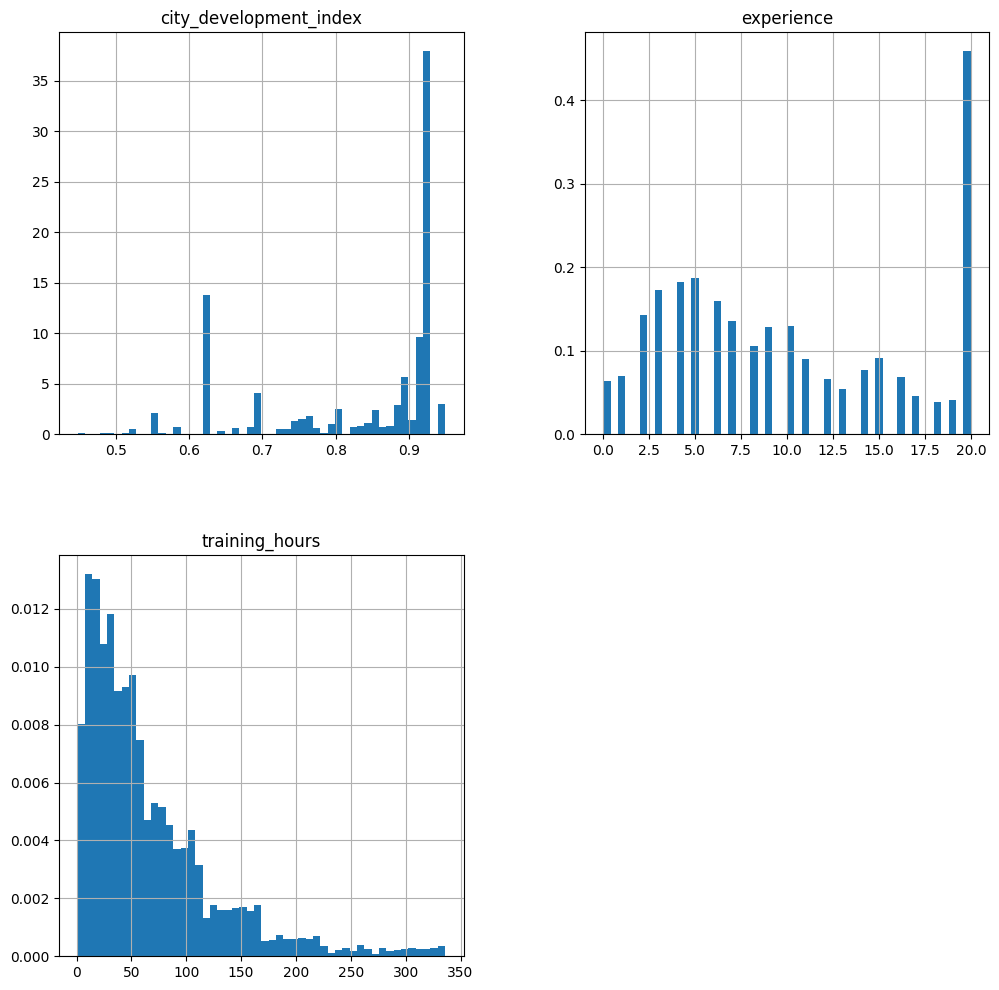

In [12]:
# we have to plot the distribution of data after removal of null values 
new_df.hist(bins=50,density=True,figsize=(12,12))
plt.show()

<Axes: >

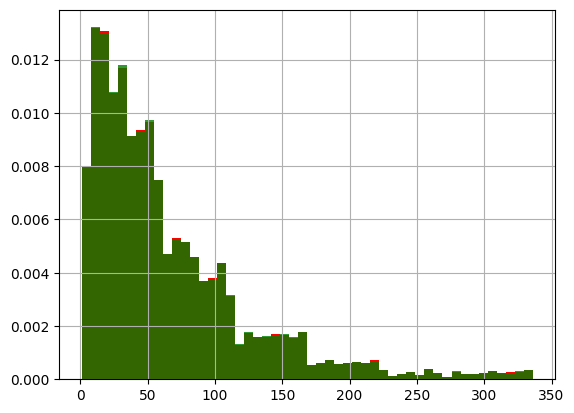

In [13]:
# now plot the overlap graph 
# of orginal dataset and dataset after removal of null values

# plot the histogram

fig  = plt.figure()
axis  =fig.add_subplot(111)

# org data
df['training_hours'].hist(bins =50, ax = axis, density =True,color ='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=axis, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

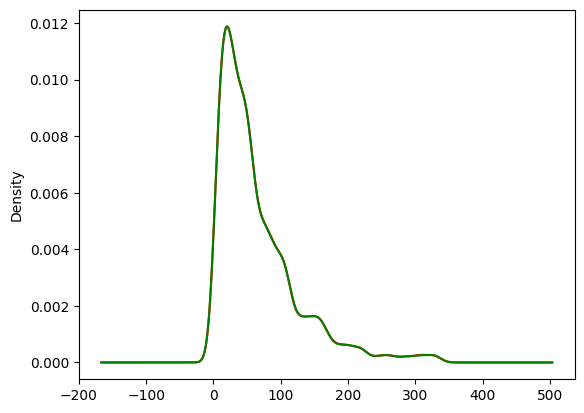

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

<Axes: >

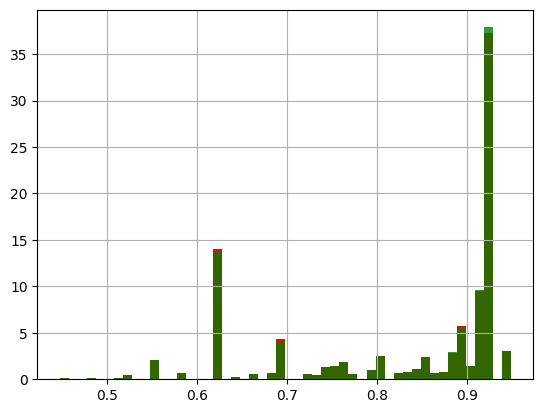

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)


<Axes: ylabel='Density'>

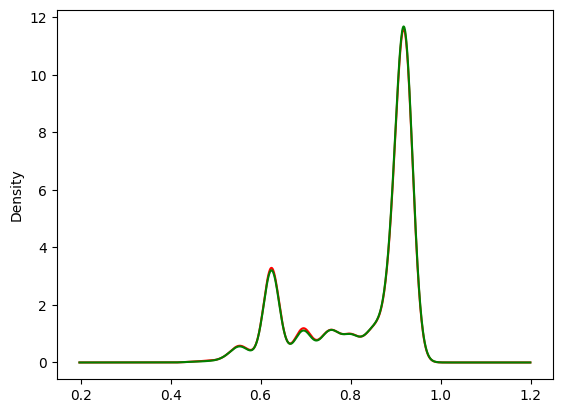

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

<Axes: >

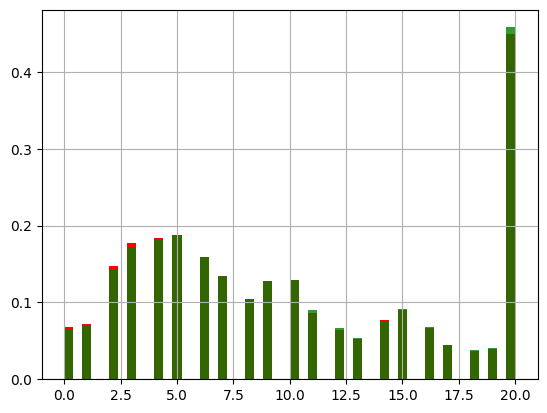

In [17]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: >

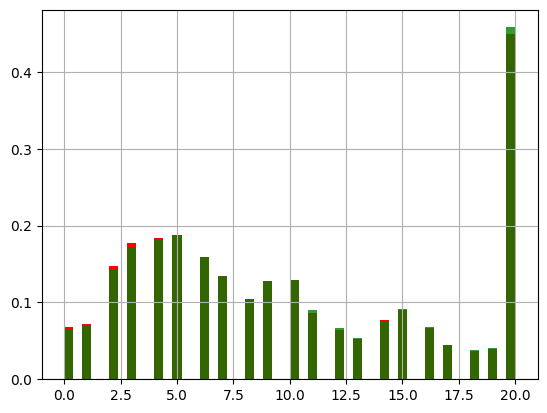

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

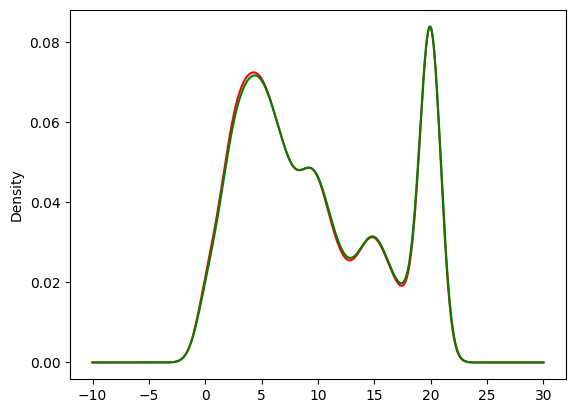

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

In [20]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [21]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


# Handling Missing Numerical data

### 1. mean and median imputation

In [22]:
# mean is used when data is fully normalized 
# median is used when data is slightly skewed
# adv and disadv

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [24]:
df = pd.read_csv("DATASET/titanic_toy.csv")

In [25]:
df.head(2)

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1


In [26]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [27]:
# independent and dependent 
X = df.drop(columns=['Survived'])
y = df['Survived']

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [29]:
print(X_train.shape)
print(X_test.shape)

(668, 3)
(223, 3)


In [30]:
# check for our train set
X_train.isnull().mean()

Age       0.197605
Fare      0.052395
Family    0.000000
dtype: float64

In [31]:
# from above we have to fill the Age and Fare 
# first find the mean and meadian
age_mean=X_train['Age'].mean()
age_median =X_train['Fare'].median()

fare_mean=X_train['Age'].mean()
fare_median =X_train['Fare'].mean()

print(f"age_mean {age_mean} and age_median {age_median} respectively")
print(f"fare_mean {fare_mean} and fare_median {fare_median} respectively")

age_mean 29.42134328358209 and age_median 14.0 respectively
fare_mean 29.42134328358209 and fare_median 32.073353712480255 respectively


In [32]:
# fillout using above values (pandas method)
X_train['Age_mean'] =X_train['Age'].fillna(age_mean)
X_train['Fare_mean'] =X_train['Fare'].fillna(fare_mean)

X_train['Age_median'] =X_train['Age'].fillna(age_median)
X_train['Fare_median'] =X_train['Fare'].fillna(fare_median)

In [33]:
X_train.sample(5)

,Age,Fare,Family,Age_mean,Fare_mean,Age_median,Fare_median
610,39.0,31.2750,6,39.0,31.2750,39.0,31.2750
414,44.0,7.9250,0,44.0,7.9250,44.0,7.9250
258,35.0,512.3292,0,35.0,512.3292,35.0,512.3292
125,12.0,11.2417,1,12.0,11.2417,12.0,11.2417
875,15.0,7.2250,0,15.0,7.2250,15.0,7.2250


In [34]:
# we need to calculate the variance before and after the filling value
# make sure that there is not a drastic change in the variance 

print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())
print()
print()
print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  211.00497090249686
Age Variance after median imputation:  207.01111311529863
Age Variance after mean imputation:  169.24686571639552


Original Fare variable variance:  2720.884465706509
Fare Variance after median imputation:  2578.1094187803806
Fare Variance after mean imputation:  2578.4591383321845


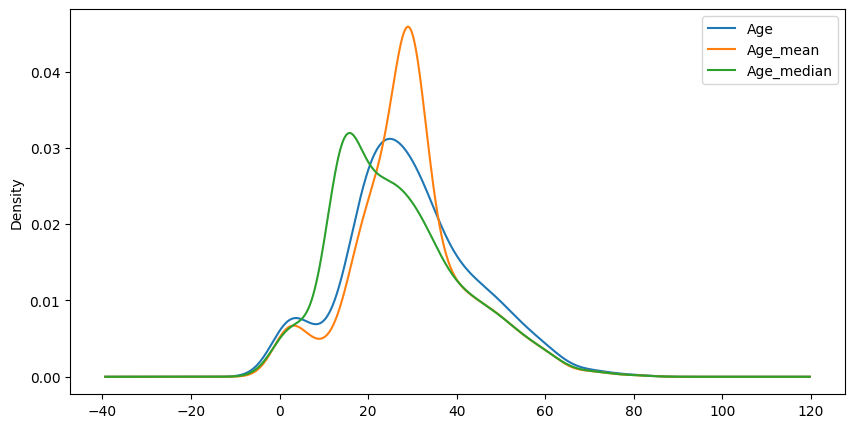

In [35]:
# plot the  kde plot for age 
fig = plt.figure(figsize=(10,5))
axis =fig.add_subplot(111)

# original distribution
X_train['Age'].plot(kind='kde',ax =axis)
# mean imputation
X_train['Age_mean'].plot(kind='kde',ax = axis)
# median imputaion
X_train['Age_median'].plot(kind ='kde',ax =axis)

lines, labels = axis.get_legend_handles_labels()
axis.legend(lines, labels, loc='best')

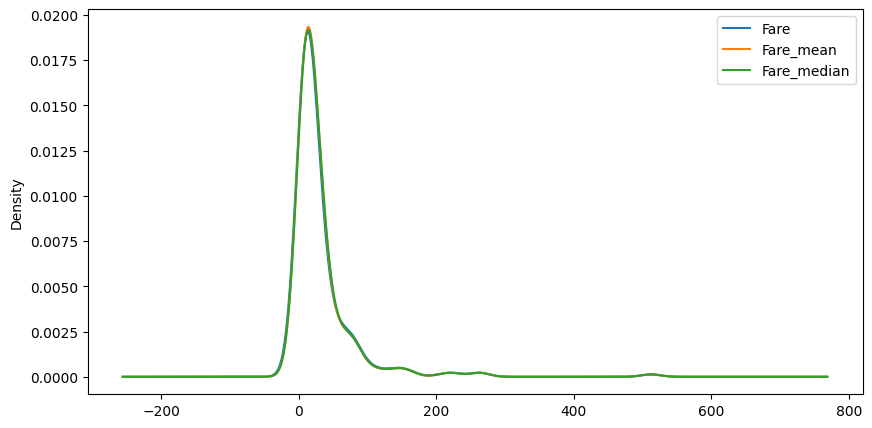

In [36]:
# plot the  kde plot for age 
fig = plt.figure(figsize=(10,5))
axis =fig.add_subplot(111)

# original distribution
X_train['Fare'].plot(kind='kde',ax =axis)
# mean imputation
X_train['Fare_mean'].plot(kind='kde',ax = axis)
# median imputaion
X_train['Fare_median'].plot(kind ='kde',ax =axis)

lines, labels = axis.get_legend_handles_labels()
axis.legend(lines, labels, loc='best')

In [37]:
# calculate the covariance 
X_train.cov()

,Age,Fare,Family,Age_mean,Fare_mean,Age_median,Fare_median
Age,211.004971,80.327854,-6.643668,211.004971,75.647474,211.004971,75.731048
Fare,80.327854,2720.884466,19.052473,64.107770,2720.884466,100.325544,2720.884466
Family,-6.643668,19.052473,2.865676,-5.328879,18.054438,-5.067217,18.052718
Age_mean,211.004971,64.107770,-5.328879,169.246866,60.676759,169.246866,60.743794
Fare_mean,75.647474,2720.884466,18.054438,60.676759,2578.459138,94.876560,2578.109419
Age_median,211.004971,100.325544,-5.067217,169.246866,94.876560,207.011113,95.061085
Fare_median,75.731048,2720.884466,18.052718,60.743794,2578.109419,95.061085,2578.109419


In [38]:
# calculate the correlation
X_train.corr()

,Age,Fare,Family,Age_mean,Fare_mean,Age_median,Fare_median
Age,1.000000,0.097852,-0.303552,1.000000,0.095180,1.000000,0.095304
Fare,0.097852,1.000000,0.212417,0.094295,1.000000,0.133387,1.000000
Family,-0.303552,0.212417,1.000000,-0.241970,0.210034,-0.208046,0.210029
Age_mean,1.000000,0.094295,-0.241970,1.000000,0.091851,0.904198,0.091958
Fare_mean,0.095180,1.000000,0.210034,0.091851,1.000000,0.129862,0.999932
Age_median,1.000000,0.133387,-0.208046,0.904198,0.129862,1.000000,0.130123
Fare_median,0.095304,1.000000,0.210029,0.091958,0.999932,0.130123,1.000000


<Axes: >

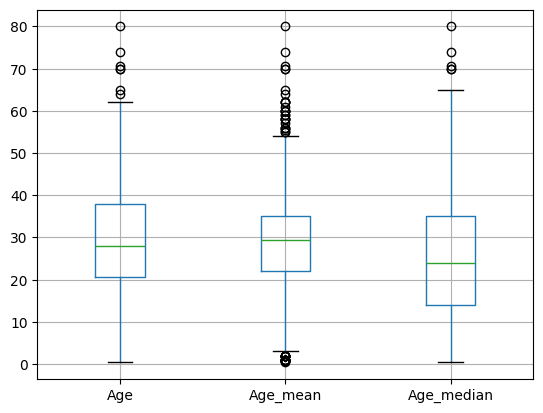

In [39]:
# plot the box plot to identify the outliers in age 
X_train[['Age','Age_mean','Age_median']].boxplot()

# from outliers we can clearly sees the mean wala column has 
# more outliers 

<Axes: >

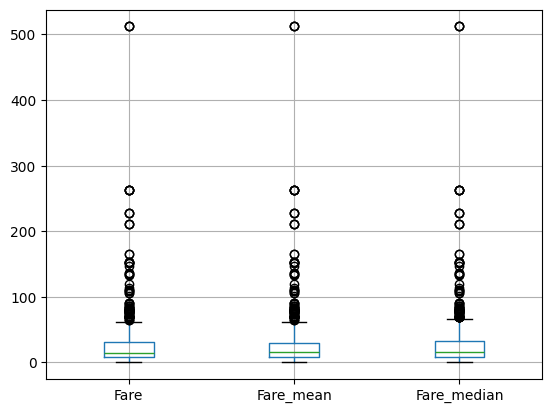

In [40]:
# plot the box plot to identify the outliers in fare
X_train[['Fare','Fare_mean','Fare_median']].boxplot()

# from outliers we can clearly sees the all have equal amount of outlier
# means distribution change nhi ho rha

#### sklearn implementation

In [41]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [42]:
imputer_1 = SimpleImputer(strategy='mean')
imputer_2 = SimpleImputer(strategy='median')

# create a transformer 
transform_impute = ColumnTransformer([
    ('impute1',imputer_1,['Age']),
    ('imputer2',imputer_2,['Fare'])
],remainder='passthrough')

# fit on training data 
transform_impute.fit(X_train)

,transformers,"[('impute1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [43]:
transform_impute.named_transformers_

{'impute1': SimpleImputer(),
 'imputer2': SimpleImputer(strategy='median'),
 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                     feature_names_out='one-to-one')}

In [44]:
# trnasform the test and train set 
X_train = transform_impute.transform(X_train)
X_test = transform_impute.transform(X_test)

In [45]:
X_train

array([[ 29.42134328,  30.5       ,   0.        ],
       [ 25.        ,   7.05      ,   0.        ],
       [ 24.        ,  14.5       ,   2.        ],
       ...,
       [ 41.        ,  14.        ,   2.        ],
       [ 14.        , 120.        ,   3.        ],
       [ 21.        ,  77.2875    ,   1.        ]], shape=(668, 3))

### 2.Arbitarily value imputation

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [47]:


# fill out values by certain number

X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [48]:
# calculate the variance 
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after 99 wala imputation: ', X_train['Age_99'].var())
print('Age Variance after -1 wala imputation: ', X_train['Age_minus1'].var())
print()
print()
print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after 999 wala imputation: ', X_train['Fare_999'].var())
print('Fare Variance after -1 wala imputation: ', X_train['Fare_minus1'].var())

Original Age variable variance:  204.34951339046142
Age Variance after 99 wala imputation:  951.7275570187188
Age Variance after -1 wala imputation:  318.0896202624488


Original Fare variable variance:  2448.1979137063163
Fare Variance after 999 wala imputation:  47219.202652176304
Fare Variance after -1 wala imputation:  2378.5676784883494


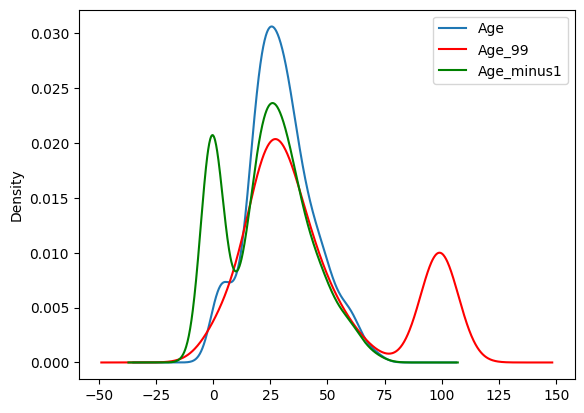

In [49]:
# plot the kde plot for age 
fig = plt.figure()
axis = fig.add_subplot(111)

# original 
X_train['Age'].plot(kind='kde', ax=axis)
# imputed with the median
X_train['Age_99'].plot(kind='kde', ax=axis, color='red')

# variable imputed with the mean
X_train['Age_minus1'].plot(kind='kde', ax=axis, color='green')

# add legends
lines, labels = axis.get_legend_handles_labels()
axis.legend(lines, labels, loc='best')

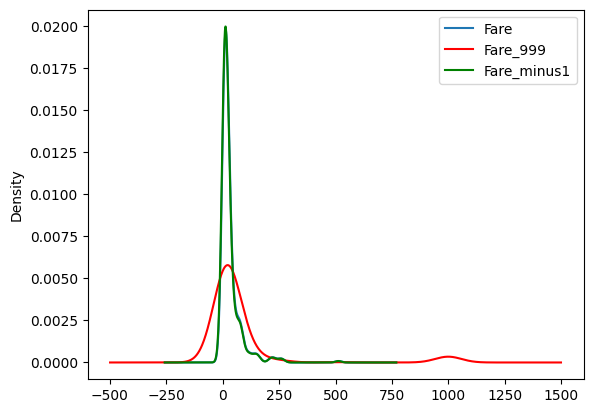

In [50]:
# plot the kde plot for fare
fig = plt.figure()
axis = fig.add_subplot(111)

# original 
X_train['Fare'].plot(kind='kde', ax=axis)
# imputed with the median
X_train['Fare_999'].plot(kind='kde', ax=axis, color='red')

# variable imputed with the mean
X_train['Fare_minus1'].plot(kind='kde', ax=axis, color='green')

# add legends
lines, labels = axis.get_legend_handles_labels()
axis.legend(lines, labels, loc='best')

In [51]:
# find out the covariance
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_minus1,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_minus1,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [52]:
# get a correlation
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_minus1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_minus1,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


#### scikit-learn imputation

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [54]:
from sklearn.impute import SimpleImputer
impute_arb1 = SimpleImputer(strategy='constant',fill_value=99)
impute_arb2 = SimpleImputer(strategy='constant',fill_value=999)

transform_arb = ColumnTransformer([
    ('imp_1',impute_arb1,['Age']),
    ('imp_2',impute_arb2,['Fare']),
],remainder='passthrough')

# fit on training data
transform_arb.fit(X_train)


,transformers,"[('imp_1', ...), ('imp_2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [55]:
print(transform_arb.named_transformers_['imp_1'].statistics_)
print(transform_arb.named_transformers_['imp_2'].statistics_)

[99.]
[999.]


In [56]:
# transform the X_train and X_test
X_train = transform_arb.transform(X_train)
X_test  = transform_arb.transform(X_test)

In [57]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]], shape=(712, 3))

### 3.End of Distribution Imputation

In [58]:
# code example 
import numpy as np
import pandas as pd 

# create a sample dataframe to perform EODI
df = pd.DataFrame({
    'Salary': [25000,27000,29000,30000,32000,
               35000,36000,np.nan,33000,np.nan]
})

# calculate the mean
mean = df['Salary'].mean()
std  = df['Salary'].std()

# EODI
eod_value =mean +3*std

# Imputation
df['Salary_EOD'] =df['Salary'].fillna(eod_value)

print("Mean :", mean)
print("Standard Deviation :", std)
print("End of Distribution Value :", eod_value)

print(df)

Mean : 30875.0
Standard Deviation : 3833.592123769634
End of Distribution Value : 42375.7763713089
    Salary    Salary_EOD
0  25000.0  25000.000000
1  27000.0  27000.000000
2  29000.0  29000.000000
3  30000.0  30000.000000
4  32000.0  32000.000000
5  35000.0  35000.000000
6  36000.0  36000.000000
7      NaN  42375.776371
8  33000.0  33000.000000
9      NaN  42375.776371


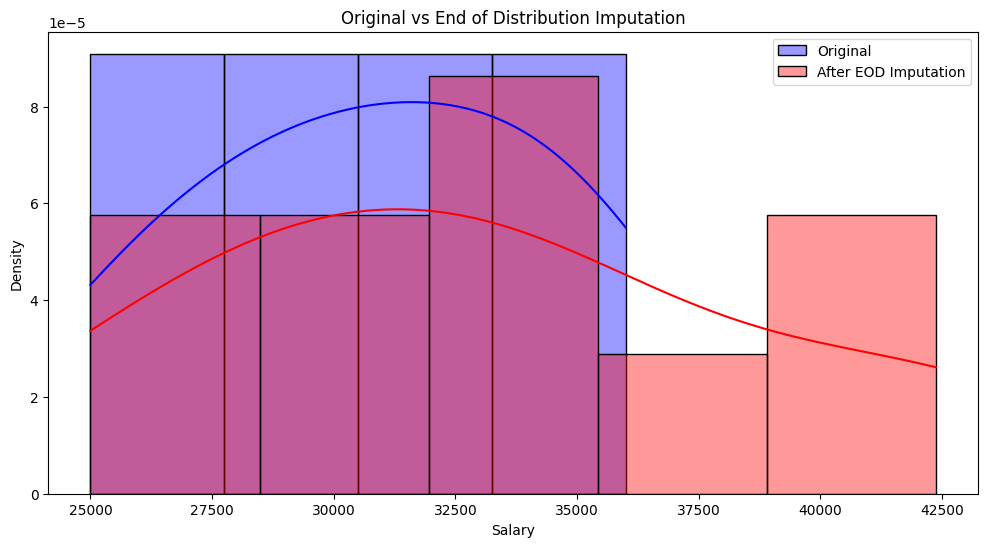

In [59]:
# plot the kde plot before and after
plt.figure(figsize=(12,6))

sns.histplot(
    df['Salary'].dropna(),
    color='blue',
    kde=True,
    stat='density',
    alpha=0.4,
    label='Original'
)

sns.histplot(
    df['Salary_EOD'],
    color='red',
    kde=True,
    stat='density',
    alpha=0.4,
    label='After EOD Imputation'
)

plt.title("Original vs End of Distribution Imputation")
plt.xlabel("Salary")
plt.ylabel("Density")
plt.legend()
plt.show()

### 4.Random sample Imputation

#### for numerical data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("DATASET/titanic.csv",usecols=['Age','Fare','Survived'])
df.head(2)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833


In [3]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [4]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [5]:
X

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [7]:
X_train

,Age,Fare
298,NaN,30.5000
884,25.00,7.0500
247,24.00,14.5000
478,22.00,7.5208
305,0.92,151.5500
...,...,...
106,21.00,7.6500
270,NaN,31.0000
860,41.00,14.1083
435,14.00,120.0000


In [8]:
#we create a new column in which we ca differentiate the null value
X_train['Age_imputed']=X_train['Age']
X_test['Age_imputed'] =X_test['Age']

In [9]:
X_test.tail()

,Age,Fare,Age_imputed
880,25.0,26.0000,25.0
425,NaN,7.2500,NaN
101,NaN,7.8958,NaN
199,24.0,13.0000,24.0
424,18.0,20.2125,18.0


In [30]:
# ya ha pe "Age_immputed" maise null value nikali  usko drop kiya and replace it with
# values present in our X_train set
# Change the sample size from 'Age' to 'Age_imputed'
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values

# Change the sample size from 'Age' to 'Age_imputed'
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values


/tmp/ipykernel_6895/1318156001.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values


In [33]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([59. , 55. , 27. , 21. , 19. , 24. , 32. , 12. , 20. , 60. , 22. ,
       36. ,  6. , 27. , 26. , 20. ,  2. , 45.5, 25. , 27. , 24. , 18. ,
       26. , 30. , 57. , 38. ,  2. , 34. ,  8. , 33. , 22. , 28. , 36. ,
       32. , 18. , 32.5, 45. , 62. , 47. , 33. , 54. , 36. ,  3. , 24. ,
       42. , 56. , 32. , 20. , 21. , 36. , 44. , 34. , 15. ,  4. , 24. ,
       18. , 31. , 35. , 29. , 34. , 27. ,  5. , 33. , 34. , 35. , 38. ,
       29. , 24. , 36. , 28. , 21. , 25. , 16. , 20. , 33. , 34. , 15. ,
       36.5, 22. , 23. , 14. , 26. , 37. ,  9. , 23. , 45. , 51. , 19. ,
        7. , 29. , 40. , 17. , 40. , 41. , 18. , 16. , 45. , 44. , 70. ,
       21. , 14.5, 33. , 33. , 31. ,  1. , 22. , 20. , 29. , 22. , 58. ,
       30. , 30. , 31. , 62. , 44. , 34. , 50. , 17. , 29. , 18. , 38. ,
       28. ,  5. , 23. , 42. , 28. , 60. , 39. , 28. , 21. , 32. , 32. ])

In [34]:
X_train['Age'].isnull().sum()

np.int64(132)

In [35]:
X_train

,Age,Fare,Age_imputed
298,NaN,30.5000,62.00
884,25.00,7.0500,25.00
247,24.00,14.5000,24.00
478,22.00,7.5208,22.00
305,0.92,151.5500,0.92
...,...,...,...
106,21.00,7.6500,21.00
270,NaN,31.0000,22.00
860,41.00,14.1083,41.00
435,14.00,120.0000,14.00


/tmp/ipykernel_6895/1648584761.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label ='original',hist=False)
/tmp/ipykernel_6895/1648584761.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label ='imputed',hist=False)


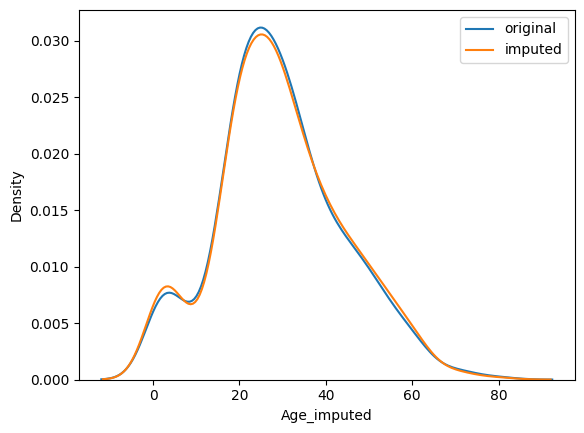

In [36]:
# plot a distplot 
sns.distplot(X_train['Age'],label ='original',hist=False)
sns.distplot(X_train['Age_imputed'],label ='imputed',hist=False)

plt.legend()
plt.show()

In [37]:
# check the variance before imputation and after imputation
print(X_train['Age'].var())
print(X_train['Age_imputed'].var())

211.00497090249686
216.95940689004297


In [38]:
# check covariance 
X_train[['Age','Fare','Age_imputed']].cov()

,Age,Fare,Age_imputed
Age,211.004971,76.431548,211.004971
Fare,76.431548,2662.974063,58.155705
Age_imputed,211.004971,58.155705,216.959407


<Axes: >

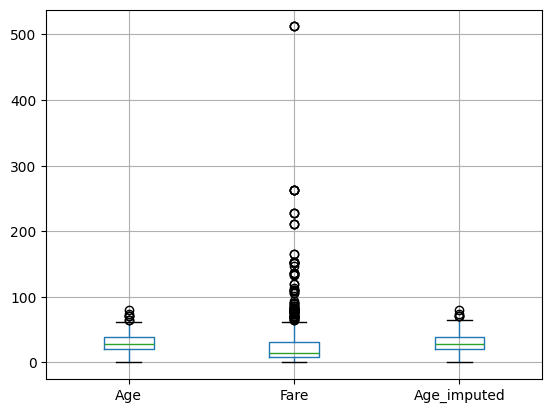

In [39]:
# check for outliers
X_train[['Age','Fare','Age_imputed']].boxplot()

#### for categorical data

In [43]:
df = pd.read_csv("DATASET/imputation.csv",usecols=['GarageQual','FireplaceQu', 'SalePrice'])
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [44]:
# null percentage 
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [45]:
# independent and dependent 
X = df
y =df['SalePrice']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [46]:

X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [47]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1212,NaN,TA,113000,TA,NaN
970,NaN,NaN,135000,NaN,NaN
317,Gd,TA,270000,TA,Gd
1303,NaN,TA,232000,TA,NaN
951,NaN,TA,119900,TA,NaN


In [48]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_6895/856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tmp

In [51]:
# concatenate the original and imputed column
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
TA,0.950820,0.951598
Fa,0.033751,0.033790
Gd,0.011572,0.010959
Ex,0.002893,0.002740
Po,0.000964,0.000913


In [52]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.490566,0.372603
TA,0.404803,0.302055
Fa,0.044597,0.031507
Ex,0.032590,0.023288
Po,0.027444,0.020548


/tmp/ipykernel_6895/2968863566.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
/tmp/ipykernel_6895/2968863566.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu

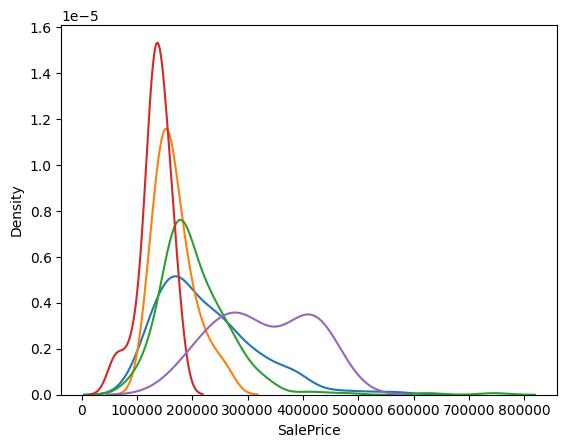

In [55]:
# plot the graph for each category
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()


### 5.Auto select Imputation 

In [44]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [45]:
df = pd.read_csv("DATASET/titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [46]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace= True)

In [47]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [48]:
X=df.drop(columns=['Survived'])
y =df['Survived']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

In [50]:
# numerical features 
num_feature =['Age','Fare']
num_transform =Pipeline(
    steps =[
        ('imputer',SimpleImputer(strategy='median')),
        ('scalar',StandardScaler())
    ]
)


In [51]:
# categorical feature
cat_feature =['Embarked','Sex']
cat_tranform =Pipeline(
    steps =[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('OHE',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [52]:
# create a columntransformer to run the pipeline
processor = ColumnTransformer(
    [
        ('num',num_transform,num_feature),
        ('cat',cat_tranform,cat_feature)
    ]
)

In [53]:
model = Pipeline(
    steps =[
        ('preprocessing',processor),
        ('classification',LogisticRegression())
    ]
)

In [54]:
from sklearn import set_config
set_config(display='diagram')
model

,steps,"[('preprocessing', ...), ('classification', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
from sklearn.model_selection import GridSearchCV

In [58]:
# apply grid search 
param_grid = {

    'preprocessing__num__imputer__strategy': ['mean', 'median'],
    'preprocessing__cat__imputer__strategy': ['most_frequent', 'constant'],
    
    
    'classification__C': [0.1, 1.0, 10, 100]
}
grid_search = GridSearchCV(model, param_grid, cv=100, scoring='accuracy')
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'classification__C': [0.1, 1.0, ...], 'preprocessing__cat__imputer__strategy': ['most_frequent', 'constant'], 'preprocessing__num__imputer__strategy': ['mean', 'median']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,100
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [59]:

print(f"Best params:")
print(grid_search.best_params_)

Best params:
{'classification__C': 0.1, 'preprocessing__cat__imputer__strategy': 'most_frequent', 'preprocessing__num__imputer__strategy': 'mean'}


In [60]:
print(f"Internal CV score: {grid_search.best_score_:.3f}")

Internal CV score: 0.786


In [62]:
import pandas as pd

# Convert results to DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Sort by highest score
cv_results = cv_results.sort_values("mean_test_score", ascending=False)

# Select columns using the updated parameter names
selected_columns = [
    'param_classification__C',
    'param_preprocessing__cat__imputer__strategy',
    'param_preprocessing__num__imputer__strategy',
    'mean_test_score'
]

# Display the top results
cv_results[selected_columns].head()


,param_classification__C,param_preprocessing__cat__imputer__strategy,param_preprocessing__num__imputer__strategy,mean_test_score
0,0.1,most_frequent,mean,0.786190
1,0.1,most_frequent,median,0.786190
2,0.1,constant,mean,0.786190
3,0.1,constant,median,0.786190
4,1.0,most_frequent,mean,0.784524


# Handling Missing Categorical data

### 1.Missing Category Imputation

In [60]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv("DATASET/imputation.csv",usecols=['GarageQual','FireplaceQu','SalePrice'])
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [62]:
# how much percent of null data
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

Text(0, 0.5, 'Number of houses')

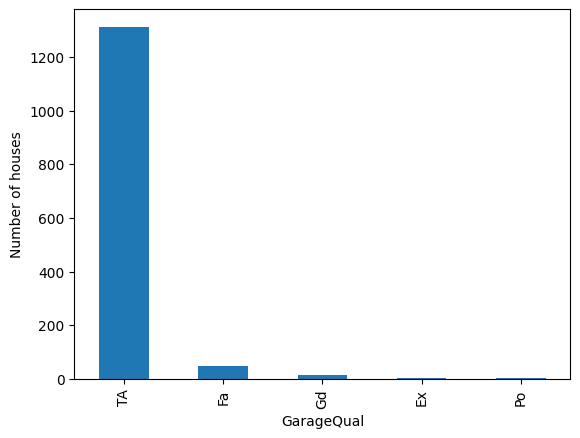

In [63]:
# plot the bar graph
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

/tmp/ipykernel_8750/1986968443.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('Missing',inplace=True)


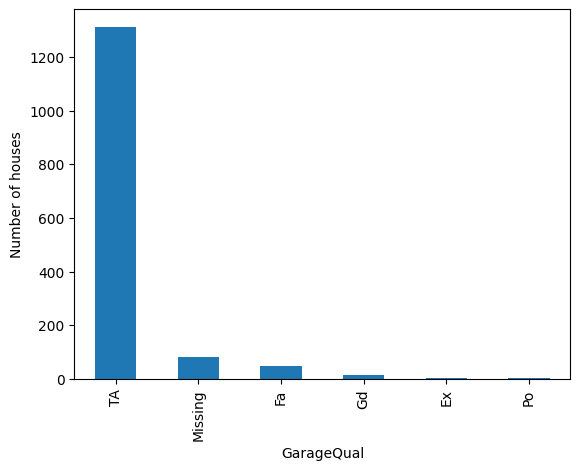

In [64]:
# fill the value (Missing)
df['GarageQual'].fillna('Missing',inplace=True)

# plot it
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')
plt.show()

# new category called Missing is created

In [65]:
X=df.drop(columns=['SalePrice'])
y=df['SalePrice']

In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [67]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='constant',fill_value='Missing')

# fit and transform
X_train = imp.fit_transform(X_train)
X_test =imp.transform(X_test)



In [68]:
imp.statistics_

array(['Missing', 'Missing'], dtype=object)

### 2.Missing frequency Imputation

In [69]:
df = pd.read_csv("DATASET/imputation.csv",usecols=['GarageQual','FireplaceQu','SalePrice'])

In [70]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [71]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

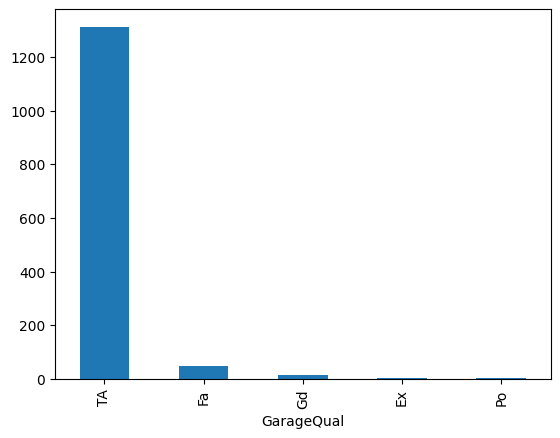

In [72]:
df['GarageQual'].value_counts().plot(kind='bar')

In [73]:
# get the mode value
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

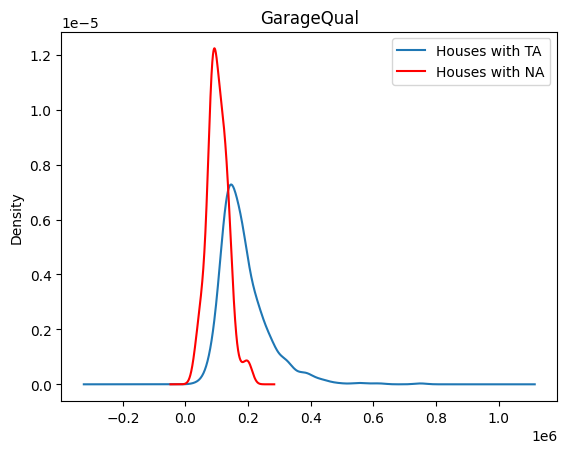

In [74]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

In [75]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [76]:
df['GarageQual'].fillna('TA', inplace=True)

/tmp/ipykernel_8750/1818999247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace=True)


<Axes: xlabel='GarageQual'>

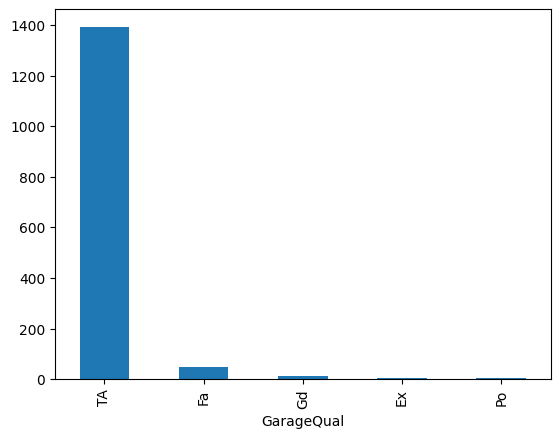

In [77]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

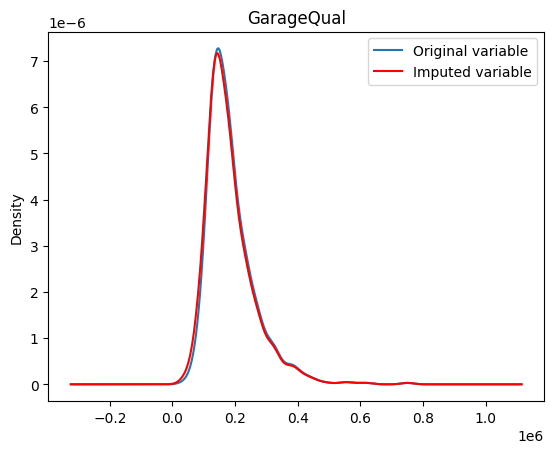

In [78]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

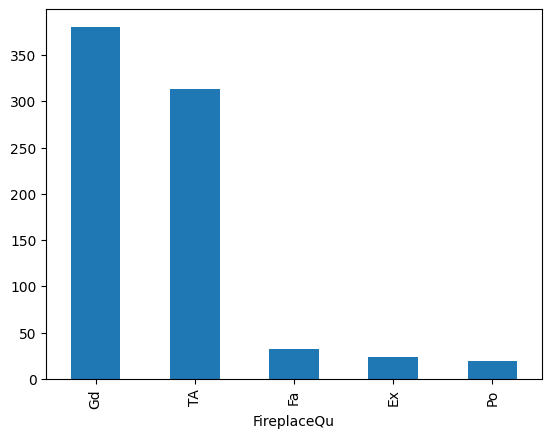

In [79]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [80]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

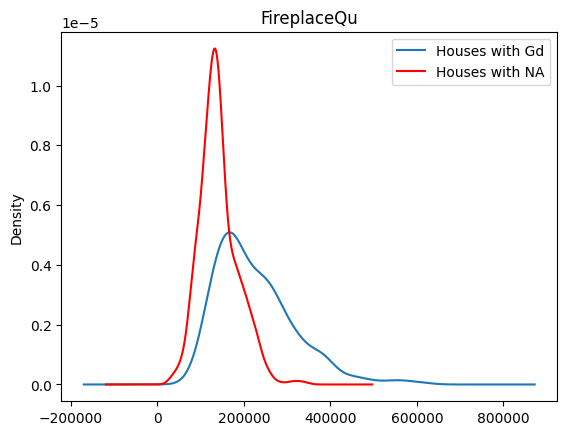

In [81]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [82]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [83]:
df['FireplaceQu'].fillna('Gd', inplace=True)

/tmp/ipykernel_8750/3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


<Axes: xlabel='FireplaceQu'>

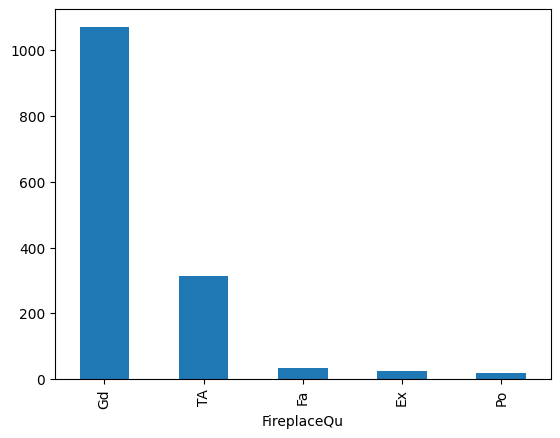

In [84]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

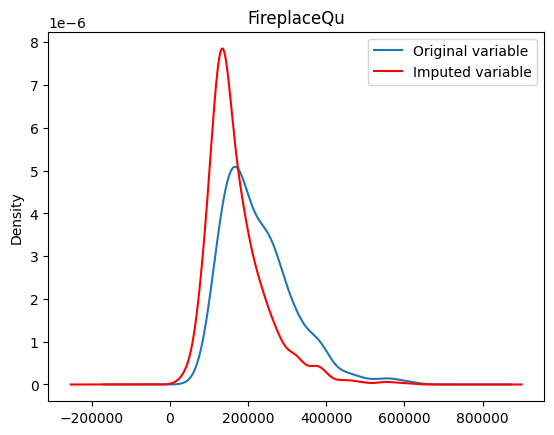

In [85]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('FireplaceQu')

In [86]:
from sklearn.model_selection import train_test_split
X =df.drop(columns=['SalePrice'])
y =df['SalePrice']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.impute import SimpleImputer
imp =SimpleImputer(strategy='most_frequent')


X_train = imp.fit_transform(X_train)
X_test = imp.transform(X_train)

/home/tushar/Desktop/MLandDL/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [87]:
imp.statistics_

array(['Gd', 'TA'], dtype=object)

# Handling Missing indicator 

In [88]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import  seaborn as sns

In [89]:
df = pd.read_csv("DATASET/titanic.csv",usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [90]:
# independent and dependent feature 
X = df.drop(columns=['Survived'])
y = df['Survived']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [91]:
X_train.head(2)

,Age,Fare
298,NaN,30.50
884,25.0,7.05


In [92]:
# apply simple imputer
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='mean')
X_train_trf = imp.fit_transform(X_train)
X_test_trf = imp.transform(X_test)

X_train_trf

array([[ 29.42134328,  30.5       ],
       [ 25.        ,   7.05      ],
       [ 24.        ,  14.5       ],
       ...,
       [ 41.        ,  14.1083    ],
       [ 14.        , 120.        ],
       [ 21.        ,  77.2875    ]], shape=(668, 2))

In [93]:
# train a classification  model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_trf,y_train)

# make a prediction

y_pred = model.predict(X_test_trf)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print(accuracy)


0.6636771300448431


### apply missing indicator 

In [94]:
from sklearn.impute import MissingIndicator
mi = MissingIndicator()
mi.fit(X_train)

,missing_values,nan
,features,'missing-only'
,sparse,'auto'
,error_on_new,True


In [95]:
# get all the feature 
mi.features_

array([0])

In [96]:
X_train_miss = mi.transform(X_train)

In [97]:
X_train_miss

array([[ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [

In [98]:
X_test_miss = mi.transform(X_test)
X_test_miss

array([[ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [100]:
# save in new column
X_train['Age_NA']=X_train_miss
X_test['Age_NA']=X_test_miss

In [102]:
X_train.sample(2)

,Age,Fare,Age_NA
74,32.0,56.4958,False
190,32.0,13.0000,False


In [105]:
# apply imputer
from sklearn.impute import SimpleImputer
si = SimpleImputer(add_indicator=True)

X_train_si = si.fit_transform(X_train)
X_test_si = si.transform(X_test)

In [106]:
# train model 
from sklearn.linear_model import LogisticRegression
model  = LogisticRegression()
model.fit(X_train_si,y_train)

y_pred = model.predict(X_test_si)

from sklearn.metrics import accuracy_score
score   = accuracy_score(y_test,y_pred)
print(score)

0.6591928251121076
